# Harvard's Endowment

## HBS Case
### *The Harvard Management Company and Inflation-Indexed Bonds*

$$
\newcommand{\mutarg}{\tilde{\boldsymbol{\mu}}^{\text{port}}}
\newcommand{\mux}{\tilde{\mu}}
\newcommand{\wEW}{\boldsymbol{\text{w}}^{\text{EW}}}
\newcommand{\wREG}{\boldsymbol{\text{w}}^{\text{REG}}}
\newcommand{\wRP}{\boldsymbol{\text{w}}^{\text{RP}}}
\newcommand{\wtan}{\boldsymbol{\text{w}}^{\text{tan}}}
$$

# 1. READING: HMC's Approach

### 1. 
There are thousands of individual risky assets in which HMC can invest.  Explain why MV optimization across 1,000 securities is infeasible.

### 2.
Rather than optimize across all securities directly, HMC runs a two-stage optimization.
1. They build asset class portfolios with each one optimized over the securities of the specific asset class.  
2. HMC combines the asset-class portfolios into one total optimized portfolio.

In order for the two-stage optimization to be a good approximation of the full MV-optimization on all assets, what must be true of the partition of securities into asset classes?

### 3.
Should TIPS form a new asset class or be grouped into one of the other 11 classes?

### 4. 
Why does HMC focus on real returns when analyzing its portfolio allocation? Is this just a matter of scaling, or does using real returns versus nominal returns potentially change the MV solution?

### 5.
The case discusses the fact that Harvard places bounds on the portfolio allocation rather than implementing whatever numbers come out of the MV optimization problem.

How might we adjust the stated optimization problem in the lecture notes to reflect the extra constraints Harvard is using in their bounded solutions given in Exhibits 5 and 6?

### 6. 
Exhibits 5 shows zero allocation to domestic equities and domestic bonds across the entire computed range of targeted returns, (5.75% to 7.25%). Conceptually, why is the constraint binding in all these cases? What would the unconstrained portfolio want to do with those allocations and why?

### 7.
Exhibit 6 changes the constraints, (tightening them in most cases.) How much deterioration do we see in the mean-variance tradeoff that Harvard achieved?

## Notes/ Answers (Not Exaustive)

1. MV Optimization across 1000 assets would be infeasiable mainly because of estimation. This would requrie 1000 expected returns and variances as well a large magnitude of covariances. With limited historical data the sample covariance matrix can not be inverted and that makes the estimates even more noisy. Since baskets of securities can be highly correlated the covariance matrix is nearly signular. Here the optimizer would amplify errors into extreme long/ short positions (without the bounds that Harvard sets). 

2. The securities must have similar return profiles and their returns (not risk necessarly) must be highly correlated. Further between each basket the correlation must be low and partition the assets well. The two stage approach does ignore security-level covariances across classes, so it works only if those covariances are small. If I can speculate on the use of the "Absolute Return" class for hedge funds is that these do not fit cleanly into any basket and these stratigies should have a cross-class covariance that is zero. 

3. It likely should be a new asset class as it measures CPI and consumer spending. While an argument could be made to share this section with domestic bonds (correlation of 0.5) the rest are 0.3 or low. TIPS also have much lower volatility (3% vs. 7%) and the opposite response to unexpected inflation, which hurts nominal bonds but is passed through to TIPS. The MV results confirm they're distinct in Exhibit 5 where we get 43 to 70% in TIPS and none in domestic bonds. 

4. We need real returns as these are funding a university where inflation will be a real cost.

5. We will use max and min constraints in our otpimization. We can gradually change these until we do not see any extreme allocations

6. The optimizer would like to hold less than 0% of these but is constrained as we can not short. MV weights depend on an asset's return relative to its covariance with the rest of the portfolio, not its standalone Sharpe ratio. Domestic bonds are dominated by TIPS, which offer similar return at a lower volitility with a 0.5 correlation so shorting bonds hedges TIPS' rate risk and funds a larger TIPS position. 

7. The deterioration is modest. At each target return, Exhibit 6's volatility is about 0.55–0.75 points higher than Exhibit 5's and Sharpe falls from .38 to .35. They only give up about 0.2 points of real return per year. 

***

# 2 Mean-Variance Optimization

### Data
You will need the file in the github repo, `data/multi_asset_etf_data.xlsx`.
- The time-series data gives monthly returns for the 11 asset classes and a short-term Treasury-bill fund return, (`SHV`.)
- The case does not give time-series data, so this data has been compiled outside of the case, and it intends to represent the main asset classes under consideration via various ETFs. For details on the specific securities/indexes, check the “Info” tab of the data.

### Excess Returns
- We consider `SHV` as the risk-free asset.
- We are going to analyze the problem in terms of **excess** returns, where `SHV` has been subtracted from the other columns.
- The risk-free rate changes over time, but the assumption is that investors know it’s value one-period ahead of time. Thus, at any given point in time, it is a risk-free rate for the next period. (This is often discussed as the "bank account" or "money market account" in other settings.)

### Adjustment
For ease of analysis, drop `QAI` from the dataset. Analyze the remaining 10 assets.

### Not Considered
- These are nominal returns-they are not adjusted for inflation, and in our calculations we are not making any adjustment for inflation.
- The exhibit data that comes via Harvard with the case is unnecessary for our analysis.

### Format
In the questions below, **annualize the statistics** you report.
- Annualize the mean of monthly returns with a scaling of 12.
- Annualize the volatility of monthly returns with a scaling of $\sqrt{12}$
- Note that we are not scaling the raw timeseries data, just the statistics computed from it (mean, vol, Sharpe).

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
from IPython.display import display


#Prices Sheet of the data
Prices = pd.read_excel('FINM Portfolio/multi_asset_etf_data.xlsx', sheet_name = 'prices', index_col = 0, parse_dates=True)

#Total Returns 
Total_Rets = pd.read_excel('FINM Portfolio/multi_asset_etf_data.xlsx', sheet_name = 'total returns', index_col = 0, parse_dates=True)

#Excess Returns
Excess_Rets = pd.read_excel('FINM Portfolio/multi_asset_etf_data.xlsx', sheet_name = 'excess returns', index_col = 0, parse_dates=True)

Rets = Excess_Rets.drop(
    columns=['QAI', 'SHV'],
    errors='ignore'
).copy()

FREQ = 12


### 1. Summary Statistics
* Calculate and display the mean and volatility of each asset’s excess return. (Recall we use volatility to refer to standard deviation.)
* Which assets have the best and worst Sharpe ratios? 

Recall that the Sharpe Ratio is simply the ratio of the mean-to-volatility of excess returns:

$$\text{sharpe ratio of investment }i = \frac{\mux_i}{\sigma_i}$$

Be sure to annualize all three statss (mean, vol, Sharpe).



In [35]:
Rets = Excess_Rets.drop(columns = 'QAI')

stats = pd.DataFrame({'Mean' : Rets.mean() * FREQ,
                      'Vol' : Rets.std() * np.sqrt(FREQ),})

stats['Sharpe'] = stats['Mean'] / stats['Vol']

stats.sort_values('Sharpe', ascending = False)

,Mean,Vol,Sharpe
SPY,0.126955,0.141398,0.897856
HYG,0.034500,0.073326,0.470501
EFA,0.063754,0.148590,0.429057
IYR,0.070095,0.165531,0.423456
PSP,0.076428,0.211323,0.361666
TIP,0.012776,0.049748,0.256817
EEM,0.044426,0.179085,0.248074
IEF,0.008596,0.062120,0.138377
DBC,0.013000,0.172276,0.075461
BWX,-0.017163,0.081891,-0.209582


By absolute value we see that SPY has the best sharpe ratio delivering the most excess returns per unit of volitility. BWX has the lowest and is negitive average excess return which means that over the sample it underperformed the risk-free rate while still carrying meaningful volatility. 

### 2. Descriptive Analysis
* Calculate the correlation matrix of the returns. Which pair has the highest correlation? And the lowest?
* How well have TIPS done in our sample? Have they outperformed domestic bonds? Foreign bonds?


,BWX,DBC,EEM,EFA,HYG,IEF,IYR,PSP,SPY,TIP
BWX,1.000,0.161,0.612,0.613,0.600,0.581,0.555,0.524,0.444,0.675
DBC,0.161,1.000,0.439,0.440,0.419,-0.309,0.253,0.420,0.384,0.084
EEM,0.612,0.439,1.000,0.812,0.670,0.051,0.574,0.697,0.693,0.384
EFA,0.613,0.440,0.812,1.000,0.776,0.063,0.700,0.862,0.833,0.402
HYG,0.600,0.419,0.670,0.776,1.000,0.193,0.731,0.798,0.783,0.540
IEF,0.581,-0.309,0.051,0.063,0.193,1.000,0.322,0.012,0.011,0.756
IYR,0.555,0.253,0.574,0.700,0.731,0.322,1.000,0.726,0.743,0.600
PSP,0.524,0.420,0.697,0.862,0.798,0.012,0.726,1.000,0.872,0.397
SPY,0.444,0.384,0.693,0.833,0.783,0.011,0.743,0.872,1.000,0.386
TIP,0.675,0.084,0.384,0.402,0.540,0.756,0.600,0.397,0.386,1.000


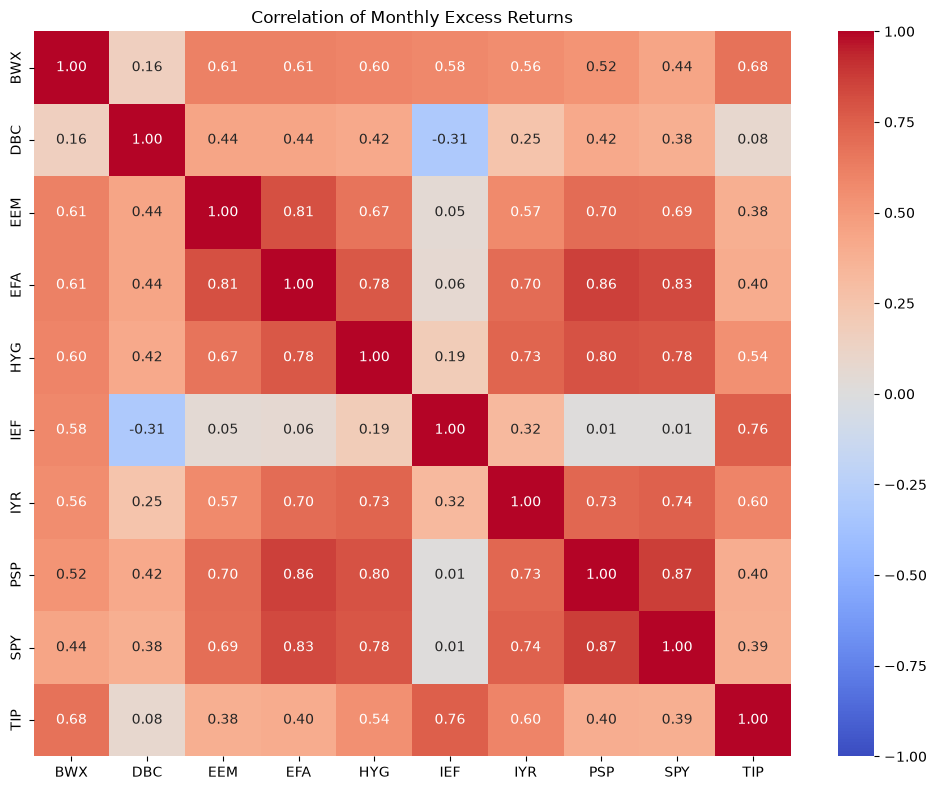

In [36]:
corr = Rets.corr()

display(corr.style.format('{:.3f}'))

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0
)
plt.title('Correlation of Monthly Excess Returns')
plt.tight_layout()
plt.show()

In [37]:
# True only above the diagonal.
upper_triangle = np.triu(
    np.ones(corr.shape, dtype=bool),
    k=1
)

pair_corr = corr.where(upper_triangle).stack()

print(
    "Highest correlation:",
    pair_corr.idxmax(),
    f"{pair_corr.max():.3f}"
)

print(
    "Lowest correlation:",
    pair_corr.idxmin(),
    f"{pair_corr.min():.3f}"
)

Highest correlation: ('PSP', 'SPY') 0.872
Lowest correlation: ('DBC', 'IEF') -0.309


In [39]:
tips_asset = 'TIP'
domestic_bond = 'IEF'
foreign_bond = 'BWX'

bond_assets = [tips_asset, domestic_bond, foreign_bond]

summary = pd.DataFrame({
    'Annualized Mean Excess Return': Rets.mean() * FREQ,
    'Annualized Volatility': Rets.std() * np.sqrt(FREQ)
})


display(
    summary.loc[bond_assets].style.format({
        'Annualized Mean Excess Return': '{:.2%}',
        'Annualized Volatility': '{:.2%}',
        'Sharpe Ratio': '{:.3f}'
    })
)

,Annualized Mean Excess Return,Annualized Volatility
TIP,1.28%,4.97%
IEF,0.86%,6.21%
BWX,-1.72%,8.19%


Tips have done well in our sample outperforming both IEF and BWX with a higher sharpe ratio. While the returns lag behind most other assets its sharpe is just below average for our sample. 


### 3. The MV frontier.
* Compute and display the weights of the tangency portfolios: $\wtan$.
* Does the ranking of weights align with the ranking of Sharpe ratios?
* Compute the mean, volatility, and Sharpe ratio for the tangency portfolio corresponding to
$\wtan$.


In [40]:
mu = Rets.mean()
cov = Rets.cov()

def tangency_weights(mu, cov):
    # Match the covariance ordering to the expected-return ordering.
    cov = cov.loc[mu.index, mu.index]

    raw_weights = np.linalg.solve(
        cov.to_numpy(),
        mu.to_numpy()
    )

    normalizer = raw_weights.sum()

    if np.isclose(normalizer, 0):
        raise ValueError(
            "The tangency weights cannot be normalized reliably."
        )

    weights = pd.Series(
        raw_weights / normalizer,
        index=mu.index,
        name='Weight'
    )

    if normalizer < 0:
        print(
            "Warning: the normalized tangency portfolio has negative "
            "expected excess return; inspect the inefficient branch."
        )

    return weights


w_tan = tangency_weights(mu, cov)

display(
    w_tan.sort_values(ascending=False)
         .to_frame()
         .style.format({'Weight': '{:.2%}'})
)

print("Sum of weights:", w_tan.sum())


,Weight
IEF,131.88%
SPY,126.32%
HYG,20.38%
EFA,18.48%
DBC,3.63%
EEM,-0.10%
TIP,-19.20%
IYR,-22.37%
PSP,-41.06%
BWX,-117.97%


Sum of weights: 1.0


In [47]:
# Annualized individual Sharpe ratios from monthly excess returns.
individual_sharpe = (
    Rets.mean() / Rets.std()
) * np.sqrt(12)

ranking = pd.DataFrame({
    'Tangency Weight': w_tan,
    'Individual Sharpe Ratio': individual_sharpe
})

ranking['Weight Rank'] = ranking['Tangency Weight'].rank(
    ascending=False,
    method='min'
)

ranking['Sharpe Rank'] = ranking['Individual Sharpe Ratio'].rank(
    ascending=False,
    method='min'
)

ranking = ranking.sort_values(
    'Tangency Weight',
    ascending=False
)

# Format a separate copy, keeping ranking numeric.
ranking_display = ranking.copy()

ranking_display['Tangency Weight'] = (
    ranking['Tangency Weight'].map('{:.2%}'.format)
)

ranking_display['Individual Sharpe Ratio'] = (
    ranking['Individual Sharpe Ratio'].map('{:.3f}'.format)
)

for column in ['Weight Rank', 'Sharpe Rank']:
    ranking_display[column] = ranking[column].map('{:.0f}'.format)

display(ranking_display)

,Tangency Weight,Individual Sharpe Ratio,Weight Rank,Sharpe Rank
IEF,131.88%,0.138,1,8
SPY,126.32%,0.898,2,1
HYG,20.38%,0.471,3,2
EFA,18.48%,0.429,4,3
DBC,3.63%,0.075,5,9
EEM,-0.10%,0.248,6,7
TIP,-19.20%,0.257,7,6
IYR,-22.37%,0.423,8,4
PSP,-41.06%,0.362,9,5
BWX,-117.97%,-0.210,10,10


In [42]:
def portfolio_stats(weights, mu, cov):
    mu = mu.loc[weights.index]
    cov = cov.loc[weights.index, weights.index]

    monthly_mean = weights @ mu
    monthly_vol = np.sqrt(weights @ cov @ weights)

    annual_mean = monthly_mean * FREQ
    annual_vol = monthly_vol * np.sqrt(FREQ)

    return pd.Series({
        'Annualized Mean Excess Return': annual_mean,
        'Annualized Volatility': annual_vol,
        'Sharpe Ratio': annual_mean / annual_vol
    })


tan_stats = portfolio_stats(w_tan, mu, cov)

display(tan_stats.to_frame('Tangency Portfolio').round(4))

,Tangency Portfolio
Annualized Mean Excess Return,0.1617
Annualized Volatility,0.1096
Sharpe Ratio,1.4758


The tangency portfolio has an annualized mean excess return of 16.17%, annualized volatility of 10.96%, and an annualized Sharpe ratio of 1.4758. Its Sharpe ratio exceeds that of every individual asset. 

The portfilio is very long IEF and SPY while very short BWX. These allocations reflect the unconstrained optimization so we are assuming we can have infinite leverage. 

The ranking of portfolio weights does not match the ranking of individual Sharpe ratios. Most notably, IEF receives the largest weight despite ranking eighth by individual Sharpe ratio. 

These differences arise because mean-variance optimization considers the covariance among assets, rather than evaluating each asset independently. An asset with a relatively low individual Sharpe ratio can be valuable because of how it interacts with the rest of the portfolio. Conversely, an asset with a positive individual Sharpe ratio can receive a negative weight if shorting it improves the portfolio’s overall risk-return tradeoff.




### 4. TIPS
Assess how much the tangency portfolio (and performance) change if...
* TIPS are dropped completely from the investment set.
* The expected excess return to TIPS is adjusted to be 0.0012 higher than what the historic sample shows.

Based on the analysis, do TIPS seem to expand the investment opportunity set, implying that Harvard should consider them as a separate asset?

In [43]:
#First removing TIPS 

Rets_no_tips = Rets.drop(columns=tips_asset)

mu_no_tips = Rets_no_tips.mean()
cov_no_tips = Rets_no_tips.cov()

w_no_tips = tangency_weights(mu_no_tips, cov_no_tips)

no_tips_stats = portfolio_stats(
    w_no_tips,
    mu_no_tips,
    cov_no_tips
)


In [44]:
#Now if we raise the TIPS excess returns 

mu_adjusted = mu.copy()

mu_adjusted.loc[tips_asset] += 0.0012

# Keep the historical covariance matrix unchanged.
w_adjusted = tangency_weights(mu_adjusted, cov)

adjusted_expected_stats = portfolio_stats(
    w_adjusted,
    mu_adjusted,
    cov
)


In [45]:
weights_comparison = pd.DataFrame({
    'Original': w_tan,
    'Without TIPS': w_no_tips,
    'Higher TIPS Expected Return': w_adjusted
}).fillna(0)

display(weights_comparison.style.format('{:.2%}'))

,Original,Without TIPS,Higher TIPS Expected Return
BWX,-117.97%,-113.75%,-86.02%
DBC,3.63%,2.58%,-4.33%
EEM,-0.10%,-0.62%,-4.02%
EFA,18.48%,18.81%,20.94%
HYG,20.38%,17.91%,1.72%
IEF,131.88%,116.16%,12.89%
IYR,-22.37%,-22.34%,-22.16%
PSP,-41.06%,-40.04%,-33.38%
SPY,126.32%,121.28%,88.19%
TIP,-19.20%,0.00%,126.17%


In [46]:
performance_comparison = pd.DataFrame({
    'Original': tan_stats,
    'Without TIPS': no_tips_stats,
    'Higher TIPS Expected Return': adjusted_expected_stats
}).T

display(
    performance_comparison.style.format({
        'Annualized Mean Excess Return': '{:.2%}',
        'Annualized Volatility': '{:.2%}',
        'Sharpe Ratio': '{:.3f}'
    })
)

,Annualized Mean Excess Return,Annualized Volatility,Sharpe Ratio
Original,16.17%,10.96%,1.476
Without TIPS,15.54%,10.54%,1.475
Higher TIPS Expected Return,13.27%,8.42%,1.575


TIPS does appear to expand the investment opportunity set, but their benefit is small under historical expected returns. 

When TIPS was removed reduces the tangency portfolio’s Sharpe ratio by 0.001. The original portfolio also takes a −19.20% short position in TIPS, so the historical results provide little support for a positive TIPS allocation.

With the increased TIPS’ expected monthly excess return the outcome does change. Here the optimal TIPS weight rises to 126.17%, and the portfolio’s Sharpe ratio increases to 1.575. While the return is lower the vol falls by more than 2%.  

This makes TIPS an attractive seperate asset in the allocation. Their incremental benefit is negligible under historical estimates but more substantial under the higher-return assumption. 

***

# 3. Allocations

* Continue with the same data file as the previous section.

* Suppose the investor has a targeted mean excess return (per month) of $\mutarg$ = 0.01.

Build the following portfolios:







#### Equally-weighted (EW)
Rescale the entire weighting vector to have target mean $\mutarg$. Thus, the $i$ element of the weight vector is,

$$\wEW_i = \frac{1}{n}$$

#### “Risk-parity” (RP)
Risk-parity is a term used in a variety of ways, but here we have in mind setting the weight of the portfolio to be proportional to the inverse of its full-sample variance estimate. Thus, the $i$ element of the weight vector is,

$$\boldsymbol{\text{w}}^{\text{RP}}_i = \frac{1}{\sigma_i^2}$$


#### Mean-Variance (MV)
As described in `Section 2`.

### Comparing

In order to compare all these allocation methods, rescale each weight vector, such that it has targeted mean return of $\mutarg$.

* Calculate the performance of each of these portfolios over the sample.
* Report their mean, volatility, and Sharpe ratio. 
* How does performance compare across allocation methods?

In [32]:
Rets = Excess_Rets.drop(columns = 'QAI')
TARGET = 0.01               # targeted mean excess return per month
mu = Rets.mean()            # monthly mean excess returns
Sigma = Rets.cov()          # monthly covariance matrix
n = len(mu)


# Raw (unscaled) weights for each method
w_raw = pd.DataFrame({
    'EW' : np.ones(n) / n,                          # equal weight: 1/n
    'RP' : 1 / Rets.var(),                          # risk parity: 1/variance
    'MV' : np.linalg.inv(Sigma)@mu,              # tangency: Sigma^-1 * mu
}, index = mu.index)

# Rescale each column so the portfolio mean (w'mu) equals the target
w = w_raw * (TARGET / (mu @ w_raw))

Port_Rets = Rets @ w

perf = pd.DataFrame({'Mean' : Port_Rets.mean() * FREQ, 'Vol'  : Port_Rets.std() * np.sqrt(FREQ)})
perf['Sharpe'] = perf['Mean'] / perf['Vol']
display((w * 100).round(1))    # weights in %
display(perf)

,EW,RP,MV
BWX,27.7,67.3,-87.6
DBC,27.7,15.2,2.7
EEM,27.7,14.1,-0.1
EFA,27.7,20.4,13.7
HYG,27.7,84.0,15.1
IEF,27.7,117.0,97.9
IYR,27.7,16.5,-16.6
PSP,27.7,10.1,-30.5
SPY,27.7,22.6,93.8
TIP,27.7,182.4,-14.2


,Mean,Vol,Sharpe
EW,0.12,0.275296,0.435894
RP,0.12,0.326142,0.367938
MV,0.12,0.081314,1.475763


- All 3 portfolio return 12% because we set it that way. MV (Mean-Variance) wins in Sharpe Ratio because it longs and shorts similar assets, so the risks partly cancel each other out. 
- EW (Equally Weighted) splits capital equally, including poor performing assets like BWX
- RP (Risk Parity) does the worst because it concentrates most of its capital into safer assets like bonds which barely earn anything. RP has to leverage in order to amplify the returns to 12%
- A caveat to the MV is that its Sharpe is based on in-sample data, and it has not been validated out-of-sample, which will look worse. 

***

# 4. EXTRA: Out-of-Sample Performance

### 1. One-step Out-of-Sample (OOS) Performance
Let’s divide the sample to both compute a portfolio and then check its performance out of sample.
* Using only data through the end of `2023`, compute the weights built in Section 3.
* Rescale the weights, (using just the in-sample data,) to set each allocation to have the same mean return of $\mu$ targ.
* Using those weights, calculate the portfolio’s Sharpe ratio within that sample.
* Again using those weights, (derived using data through `2023`,) calculate the portfolio’s OOS Sharpe ratio, which is based only on performance in `2024-2025`.

In [50]:
#Helper function from ChatGPT 
def get_weights(train, target=0.01):
    """Build EW, RP, MV, and REG portfolios targeting
    a specified monthly mean excess return.
    """
    mu = train.mean()
    cov = train.cov()

    # Keep variances unchanged and halve covariances.
    cov_diagonal = pd.DataFrame(
        np.diag(np.diag(cov)),
        index=cov.index,
        columns=cov.columns
    )

    cov_reg = (cov + cov_diagonal) / 2

    # Initial allocations.
    raw = pd.DataFrame(index=train.columns)

    raw['EW'] = 1 / train.shape[1]

    # Assignment's RP definition: inverse variance.
    raw['RP'] = 1 / train.var()

    raw['MV'] = np.linalg.solve(
        cov.to_numpy(),
        mu.to_numpy()
    )

    raw['REG'] = np.linalg.solve(
        cov_reg.to_numpy(),
        mu.to_numpy()
    )

    # Scale each portfolio to the target monthly excess return.
    initial_means = raw.T @ mu

    if np.isclose(initial_means.to_numpy(), 0).any():
        raise ValueError(
            "A portfolio's estimated mean is too close to zero "
            "to scale reliably."
        )

    weights = raw.mul(
        target / initial_means,
        axis='columns'
    )

    return weights

In [54]:
def performance(returns):
    annual_mean = returns.mean() * 12
    annual_vol = returns.std() * np.sqrt(12)

    return pd.DataFrame({
        'Annualized Mean Excess Return': annual_mean,
        'Annualized Volatility': annual_vol,
        'Sharpe Ratio': annual_mean / annual_vol
    })


def show_performance(table):
    formatted = table.copy()

    for column in [
        'Annualized Mean Excess Return',
        'Annualized Volatility'
    ]:
        formatted[column] = formatted[column].map('{:.2%}'.format)

    formatted['Sharpe Ratio'] = (
        formatted['Sharpe Ratio'].map('{:.3f}'.format)
    )

    display(formatted)


# Split the data.
train = Rets.loc[:'2023-12-31']
test = Rets.loc['2024-01-01':'2025-12-31']

if train.empty or test.empty:
    raise ValueError(
        "Check that your data includes the training period "
        "and observations in 2024–2025."
    )

# Estimate and scale weights using training data only.
weights_2023 = get_weights(train)

print("Weights estimated through December 2023:")
display(
    weights_2023.apply(
        lambda col: col.map('{:.2%}'.format)
    )
)

# Verify the training-sample monthly mean is 1%.
print("Training-sample monthly mean excess returns:")
display((weights_2023.T @ train.mean()).round(6))

# Apply identical weights to both periods.
in_sample_returns = train @ weights_2023
out_sample_returns = test @ weights_2023

# Report annualized performance.
in_sample_stats = performance(in_sample_returns)
out_sample_stats = performance(out_sample_returns)

step1_results = pd.concat(
    {
        'In Sample: Through 2023': in_sample_stats,
        'Out of Sample: 2024–2025': out_sample_stats
    },
    names=['Period', 'Portfolio']
)

show_performance(step1_results)

# Direct comparison of Sharpe ratios.
step1_sharpes = pd.DataFrame({
    'In-Sample Sharpe': in_sample_stats['Sharpe Ratio'],
    'Out-of-Sample Sharpe': out_sample_stats['Sharpe Ratio']
})

print("Sharpe ratio comparison:")
display(step1_sharpes.round(3))

Weights estimated through December 2023:


,EW,RP,MV,REG
BWX,29.73%,68.17%,-86.89%,-71.52%
DBC,29.73%,15.19%,-1.01%,-12.99%
EEM,29.73%,13.47%,5.11%,-10.16%
EFA,29.73%,18.78%,-14.09%,2.92%
HYG,29.73%,72.26%,15.28%,32.00%
IEF,29.73%,112.85%,103.87%,43.49%
IYR,29.73%,15.63%,-19.91%,8.47%
PSP,29.73%,9.37%,-21.70%,4.15%
SPY,29.73%,21.34%,107.77%,63.21%
TIP,29.73%,167.53%,-10.61%,35.69%


Training-sample monthly mean excess returns:


EW     0.01
RP     0.01
MV     0.01
REG    0.01
dtype: float64

Annualized Mean Excess Return  \
Period                   Portfolio                                 
In Sample: Through 2023  EW                               12.00%   
                         RP                               12.00%   
                         MV                               12.00%   
                         REG                              12.00%   
Out of Sample: 2024–2025 EW                               14.26%   
                         RP                                6.63%   
                         MV                               16.76%   
                         REG                              12.02%   

                                   Annualized Volatility Sharpe Ratio  
Period                   Portfolio                                     
In Sample: Through 2023  EW                       31.13%        0.386  
                         RP                       31.66%        0.379  
                         MV                        8.25%        1.455  
                         REG                      10.70%        1.122  
Out of Sample: 2024–2025 EW                       17.76%        0.803  
                         RP                       24.53%        0.270  
                         MV                       11.04%        1.518  
                         REG                       9.16%        1.312

Sharpe ratio comparison:


,In-Sample Sharpe,Out-of-Sample Sharpe
EW,0.386,0.803
RP,0.379,0.270
MV,1.455,1.518
REG,1.122,1.312


### 2. Rolling OOS Performance

Iterate the Out-of-Sample performance every year, not just the final year. Namely,
* Start at the end of `2015`, and calculate the weights through that time. Rescale them using the mean returns through that time.
* Apply the weights to the returns in the upcoming year, (`2016`.)
* Step forward a year in time, and recompute.
* Continue until again calculating the weights through `2023` and applying them to the returns in `2024-2025`.

Report the mean, volatility, and Sharpe from this dynamic approach for the following portfolios:
* mean-variance (tangency)
* equally-weighted
* risk-parity
* regularized

In [55]:
oos_parts = []
weights_by_year = {}
period_records = []

for estimation_year in range(2015, 2024):
    train_end = f'{estimation_year}-12-31'
    test_start = f'{estimation_year + 1}-01-01'

    # The assignment's final test block includes two years.
    if estimation_year == 2023:
        test_end = '2025-12-31'
    else:
        test_end = f'{estimation_year + 1}-12-31'

    # Expanding training sample.
    train_year = Rets.loc[:train_end]
    test_year = Rets.loc[test_start:test_end]

    if len(train_year) < 2 or test_year.empty:
        raise ValueError(
            f"Insufficient data for the allocation "
            f"estimated through {estimation_year}."
        )

    # Estimate and scale using only information available
    # at this training endpoint.
    weights = get_weights(train_year)

    weights_by_year[estimation_year] = weights

    # Apply weights to the subsequent test period.
    period_returns = test_year @ weights
    oos_parts.append(period_returns)

    period_records.append({
        'Estimation Year': estimation_year,
        'Training Months': len(train_year),
        'Test Start': test_year.index.min(),
        'Test End': test_year.index.max(),
        'Test Months': len(test_year)
    })

# Join the non-overlapping test periods into one return series.
rolling_oos_returns = pd.concat(oos_parts).sort_index()

if rolling_oos_returns.index.has_duplicates:
    raise ValueError("The out-of-sample periods overlap.")

# Calculate performance over the complete OOS return history.
rolling_results = performance(rolling_oos_returns)

print("Expanding-sample out-of-sample performance:")
show_performance(rolling_results)

print("Training and test periods:")
display(pd.DataFrame(period_records))

Expanding-sample out-of-sample performance:


,Annualized Mean Excess Return,Annualized Volatility,Sharpe Ratio
EW,18.26%,29.37%,0.622
RP,8.57%,25.92%,0.331
MV,7.45%,9.56%,0.780
REG,6.41%,10.76%,0.596


Training and test periods:


,Estimation Year,Training Months,Test Start,Test End,Test Months
0,2015,59,2016-01-31,2016-12-31,12
1,2016,71,2017-01-31,2017-12-31,12
2,2017,83,2018-01-31,2018-12-31,12
3,2018,95,2019-01-31,2019-12-31,12
4,2019,107,2020-01-31,2020-12-31,12
5,2020,119,2021-01-31,2021-12-31,12
6,2021,131,2022-01-31,2022-12-31,12
7,2022,143,2023-01-31,2023-12-31,12
8,2023,155,2024-01-31,2025-12-31,24


***

# 5. EXTRA: Without a Riskless Asset

Re-do Section 2 above, but in the model without a risk-free rate.

That is, build the MV allocation using the two-part formula in the `Mean-Variance` section of the notes.
* This essentially substitutes the risk-free rate with the minimum-variance portfolio.
* Now, the allocation depends nonlinearly on the target mean return, $\mu$ targ. (With a risk-free rate, we simply scale the weights up and down to achieve the mean return.)

You will find that, conceptually, the answers are very similar.

***

# 6. EXTRA: Bayesian Allocation

Add the following allocation among the choices in `Section 3`...

#### Regularized (REG)
Much like the Mean-Variance portfolio, set the weights proportional to 

$$REG \sim \widehat{\Sigma}^{-1}\mux$$

but this time, use a regularized covariance matrix,

$$\widehat{\Sigma} = \frac{\Sigma + \Sigma_D}{2}$$

where $\Sigma_D$ denotes a *diagonal* matrix of the security variances, with zeros in the off-diagonals.

Thus, $\widehat{\Sigma}$ is obtained from the usual covariance matrix, $\Sigma$, but shrinking all the covariances to half their estimated values.

In [56]:
mu = Rets.mean()
cov = Rets.cov()

cov_diagonal = pd.DataFrame(
    np.diag(np.diag(cov)),
    index=cov.index,
    columns=cov.columns
)

cov_reg = (cov + cov_diagonal) / 2

raw_reg = pd.Series(
    np.linalg.solve(cov_reg.to_numpy(), mu.to_numpy()),
    index=mu.index
)

# Scale weights to target a 1% monthly excess return.
target_mean = 0.01
raw_mean = raw_reg @ mu

if np.isclose(raw_mean, 0):
    raise ValueError("Estimated mean is too close to zero to scale.")

w_reg = raw_reg * (target_mean / raw_mean)

print("Regularized portfolio weights:")
display(
    w_reg.to_frame('REG Weight').apply(
        lambda col: col.map(lambda x: f'{x:.2%}')
    )
)

print(f"Sum of risky-asset weights: {w_reg.sum():.2%}")
print(f"Implied risk-free weight: {1 - w_reg.sum():.2%}")

reg_rets = Rets @ w_reg

annual_mean = reg_rets.mean() * 12
annual_vol = reg_rets.std() * np.sqrt(12)
sharpe = annual_mean / annual_vol

reg_performance = pd.DataFrame({
    'Annualized Mean Excess Return': [annual_mean],
    'Annualized Volatility': [annual_vol],
    'Sharpe Ratio': [sharpe]
}, index=['REG'])

display(reg_performance.round(4))


Regularized portfolio weights:


,REG Weight
BWX,-78.68%
DBC,-5.51%
EEM,-1.17%
EFA,10.90%
HYG,29.56%
IEF,36.08%
IYR,6.62%
PSP,-2.03%
SPY,64.09%
TIP,23.75%


Sum of risky-asset weights: 83.61%
Implied risk-free weight: 16.39%


,Annualized Mean Excess Return,Annualized Volatility,Sharpe Ratio
REG,0.12,0.1051,1.1413


# 7. EXTRA: Inefficient Tangency

Return to analyzing the excess returns, as in `Section 3`. Include the hedge-fund ETF, QAI.

You might find that the tangency portfolio has a negative mean return. 
- It is on the inefficient portion of the MV frontier.

Calculate the optimal allocation by shorting the tangency portfolio. (That is, multiply the tangency weights by negative one to determine the allocation weights.)

Re-do the analysis of Section 3. Does the addition of `QAI` change much.